In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

##### 1. IMPORT

In [38]:
data = pd.read_csv("data_ori.csv")
data_raw = data.copy()
print(f"ukura data: {data_raw.shape}")

ukura data: (1460, 81)


In [39]:
data_raw.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [40]:
data_raw.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [41]:
data_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [42]:
print(f"data duplikat: {data_raw.duplicated().sum()}")

data duplikat: 0


In [43]:
data_fitur = [col for col in data_raw.columns if col not in ["Id", "SalePrice"]]
kolom_numerik = data_raw[data_fitur].select_dtypes(include=np.number).columns.tolist()
kolom_kateforikal = data_raw[data_fitur].select_dtypes(exclude=np.number).columns.tolist()

print(f"jumlah data numerik: {len(kolom_numerik)}")
print(f"jumlah data kategorikal: {len(kolom_kateforikal)}")

jumlah data numerik: 36
jumlah data kategorikal: 43


Dataset awal diperiksa menggunakan fungsi head(), shape, dan info(). Kolom Id diperlakukan sebagai identifier dan tidak digunakan sebagai fitur analisis, sedangkan SalePrice dipertahankan sebagai variabel target. Fitur kemudian dikelompokkan menjadi atribut numerik dan kategoris berdasarkan tipe datanya.

#### 2. pembersihan data dan missing value

In [44]:
jumlah_hilang = data_raw.isnull().sum()
persentase_hilang = data_raw.isnull().mean() * 100

data_hilang = pd.DataFrame({
    "Jumlah Missing": jumlah_hilang,
    "Persentase Missing (%)": persentase_hilang
})

data_hilang = (
    data_hilang[data_hilang["Jumlah Missing"] > 0]
    .sort_values("Persentase Missing (%)", ascending=False)
)

display(data_hilang)

,Jumlah Missing,Persentase Missing (%)
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


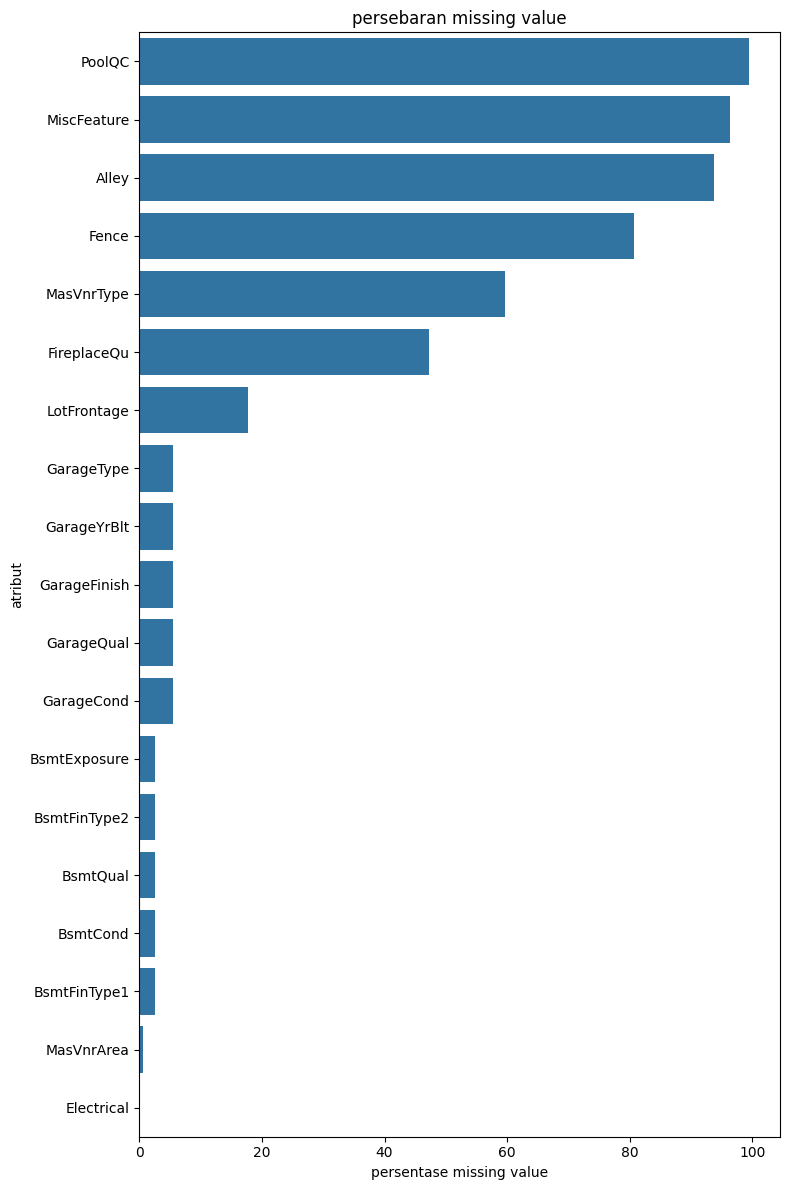

In [45]:
plt.figure(figsize=(8, 12))
sns.barplot(
    data= data_hilang.reset_index(),
    x= "Persentase Missing (%)",
    y= "index"
)
plt.title("persebaran missing value")
plt.xlabel("persentase missing value")
plt.ylabel("atribut")
plt.tight_layout()
plt.show()

In [46]:
data_clean = data_raw.drop(columns=persentase_hilang[persentase_hilang > 50].index.tolist()).copy()

In [47]:
data_clean.shape

(1460, 76)

In [48]:
data_fitur_clean = [col for col in data_clean.columns if col not in ["Id", "SalePrice"]]
kolom_numerik_clean = data_clean[data_fitur_clean].select_dtypes(include=np.number).columns.tolist()
kolom_kateforikal_clean = data_clean[data_fitur_clean].select_dtypes(exclude=np.number).columns.tolist()

print(f"jumlah data numerik: {len(kolom_numerik)}")
print(f"jumlah data kategorikal: {len(kolom_kateforikal_clean)}")

jumlah data numerik: 36
jumlah data kategorikal: 38


In [49]:
for col in kolom_numerik_clean:
    if data_clean[col].isnull().sum() > 0:
        data_clean[col] = data_clean[col].fillna(data_clean[col].median())

In [50]:
for col in kolom_kateforikal_clean:
    if data_clean[col].isnull().sum() > 0:
        data_clean[col] = data_clean[col].fillna(data_clean[col].mode()[0])

In [51]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 76 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [52]:
data_clean_duplikat = data_clean.duplicated().sum()
print(f"jumlah duplikat di data clean: {data_clean_duplikat}")

jumlah duplikat di data clean: 0


Imputasi dilakukan berdasarkan tipe data secara umum. Interpretasi semantik setiap atribut dapat menjadi pengembangan berikutnya karena pada atribut tertentu, nilai kosong mungkin memiliki arti tidak tersedianya fasilitas.

#### 3. deteksi dan penanganan outlier

In [53]:
candidate_outlier_columns = [
    "LotArea",
    "GrLivArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "GarageArea",
    "YearBuilt"
]

outlier_columns = [
    col for col in candidate_outlier_columns
    if col in data_clean.columns
]

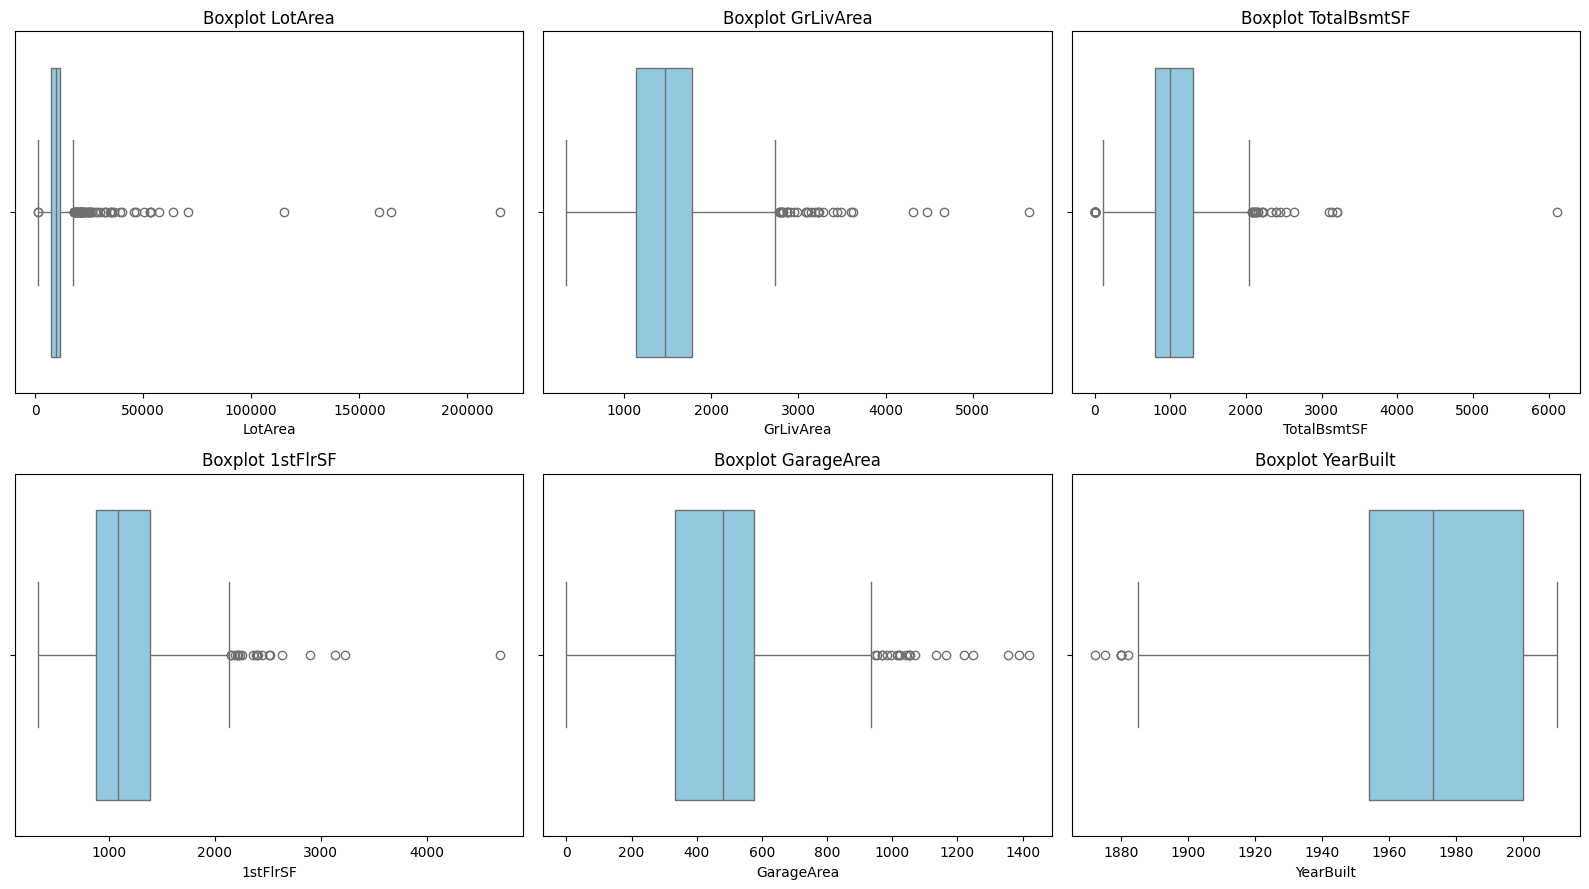

In [54]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(16, 9)
)

axes = axes.flatten()

for index, col in enumerate(outlier_columns):
    sns.boxplot(
        x=data_clean[col],
        ax=axes[index],
        color="skyblue"
    )
    axes[index].set_title(f"Boxplot {col}")

for index in range(len(outlier_columns), len(axes)):
    axes[index].axis("off")

plt.tight_layout()
plt.show()

In [55]:
def calculate_outlier_summary(data, columns):
    result = []

    for col in columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outlier_count = (
            (data[col] < lower_bound) |
            (data[col] > upper_bound)
        ).sum()

        result.append({
            "Atribut": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Batas Bawah": lower_bound,
            "Batas Atas": upper_bound,
            "Jumlah Outlier": outlier_count
        })

    return pd.DataFrame(result)

outlier_summary = calculate_outlier_summary(
    data_clean,
    outlier_columns
)

display(outlier_summary)

,Atribut,Q1,Q3,IQR,Batas Bawah,Batas Atas,Jumlah Outlier
0,LotArea,7553.50,11601.50,4048.00,1481.500,17673.500,69
1,GrLivArea,1129.50,1776.75,647.25,158.625,2747.625,31
2,TotalBsmtSF,795.75,1298.25,502.50,42.000,2052.000,61
3,1stFlrSF,882.00,1391.25,509.25,118.125,2155.125,20
4,GarageArea,334.50,576.00,241.50,-27.750,938.250,21
5,YearBuilt,1954.00,2000.00,46.00,1885.000,2069.000,7


In [56]:
df_outlier_handled = data_clean.copy()

outlier_bounds = {}

for col in outlier_columns:
    q1 = df_outlier_handled[col].quantile(0.25)
    q3 = df_outlier_handled[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_bounds[col] = {
        "lower_bound": lower_bound,
        "upper_bound": upper_bound
    }

    df_outlier_handled[col] = df_outlier_handled[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

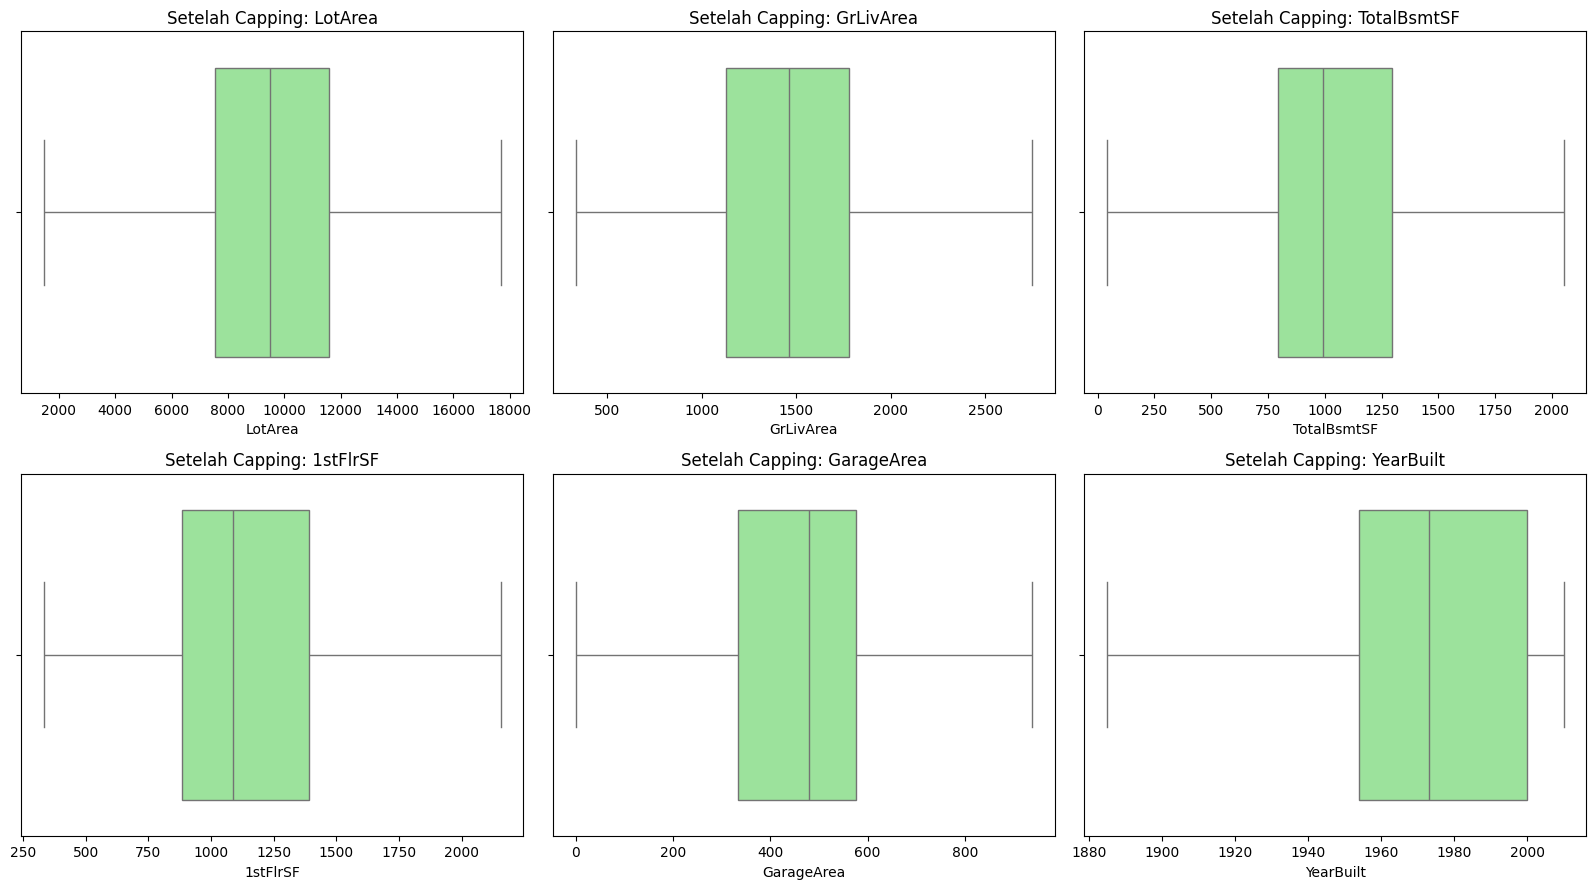

In [57]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(16, 9)
)

axes = axes.flatten()

for index, col in enumerate(outlier_columns):
    sns.boxplot(
        x=df_outlier_handled[col],
        ax=axes[index],
        color="lightgreen"
    )
    axes[index].set_title(f"Setelah Capping: {col}")

for index in range(len(outlier_columns), len(axes)):
    axes[index].axis("off")

plt.tight_layout()
plt.show()

Outlier ditangani menggunakan IQR capping. Nilai yang berada di bawah batas bawah atau di atas batas atas disesuaikan ke batas IQR terdekat. Metode ini dipilih agar ukuran dataset tetap terjaga dan informasi dari suatu data tidak hilang seluruhnya hanya karena memiliki nilai ekstrem pada salah satu atribut.

#### 4. reduksi fitur

In [58]:
id_values = df_outlier_handled["Id"].copy()
target_values = df_outlier_handled["SalePrice"].copy()

X = df_outlier_handled.drop(
    columns=["Id", "SalePrice"]
).copy()

y = target_values.copy()

In [59]:
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

correlation_matrix = X[numeric_features].corr()

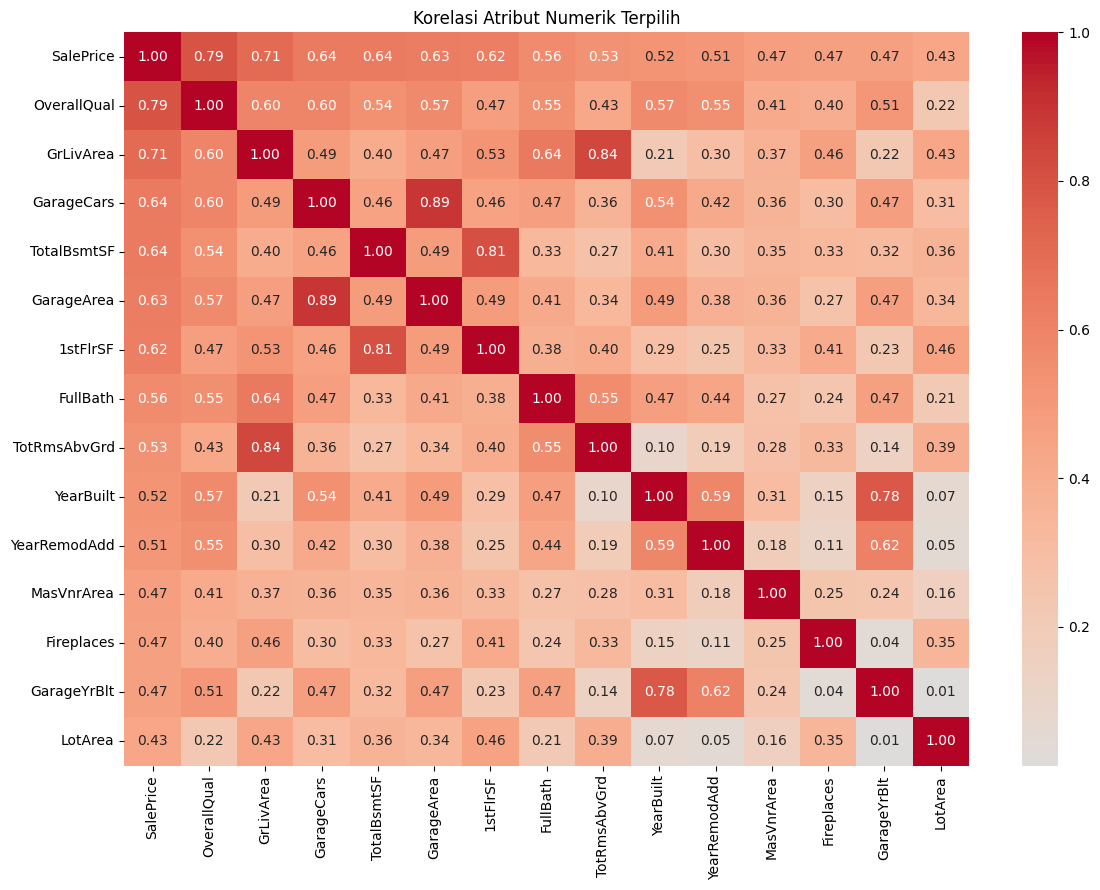

In [60]:
correlation_with_target = (
    df_outlier_handled
    .select_dtypes(include=np.number)
    .corr()["SalePrice"]
    .abs()
    .sort_values(ascending=False)
)

top_correlated_columns = (
    correlation_with_target
    .head(15)
    .index
    .tolist()
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    df_outlier_handled[top_correlated_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Korelasi Atribut Numerik Terpilih")
plt.tight_layout()
plt.show()

In [61]:
correlation_threshold = 0.90

upper_triangle = correlation_matrix.where(
    np.triu(
        np.ones(correlation_matrix.shape),
        k=1
    ).astype(bool)
)

high_correlation_pairs = []

for column in upper_triangle.columns:
    correlated_rows = upper_triangle.index[
        upper_triangle[column].abs() > correlation_threshold
    ].tolist()

    for row in correlated_rows:
        high_correlation_pairs.append({
            "Fitur 1": row,
            "Fitur 2": column,
            "Korelasi": upper_triangle.loc[row, column]
        })

high_correlation_df = pd.DataFrame(high_correlation_pairs)
display(high_correlation_df)

""


In [62]:
columns_to_drop_correlation = [
    column
    for column in upper_triangle.columns
    if any(
        upper_triangle[column].abs() > correlation_threshold
    )
]

print("Kolom yang dibuang karena korelasi tinggi:")
print(columns_to_drop_correlation)

X_reduced = X.drop(
    columns=columns_to_drop_correlation
).copy()

print("Dimensi sebelum reduksi korelasi:", X.shape)
print("Dimensi setelah reduksi korelasi:", X_reduced.shape)

Kolom yang dibuang karena korelasi tinggi:
[]
Dimensi sebelum reduksi korelasi: (1460, 74)
Dimensi setelah reduksi korelasi: (1460, 74)


Hasil Reduksi Fitur Berdasarkan Korelasi

Analisis korelasi dilakukan terhadap fitur numerik menggunakan
korelasi Pearson. Pasangan fitur diperiksa menggunakan matriks
korelasi segitiga atas agar setiap pasangan tidak dihitung dua kali.

Ambang yang digunakan adalah nilai korelasi absolut lebih besar
dari 0,90. Berdasarkan hasil pemeriksaan, tidak ditemukan pasangan
fitur yang memenuhi kriteria tersebut. Oleh karena itu, tidak ada
fitur yang dihapus pada tahap reduksi berbasis korelasi.

Keputusan mempertahankan seluruh fitur dilakukan agar informasi
tidak dihilangkan tanpa dasar yang memenuhi ambang yang telah
ditetapkan. Reduksi dimensi selanjutnya dilakukan menggunakan PCA
setelah proses standardisasi dan one-hot encoding.

#### 5. encoding dan standarisasi

In [63]:
numerical_features = X_reduced.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_reduced.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Jumlah fitur numerik:", len(numerical_features))
print("Jumlah fitur kategoris:", len(categorical_features))

Jumlah fitur numerik: 36
Jumlah fitur kategoris: 38


In [64]:
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [65]:
X_transformed_array = preprocessor.fit_transform(X_reduced)

In [66]:
encoded_feature_names = (
    preprocessor
    .named_transformers_["categorical"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
)

all_feature_names = (
    numerical_features +
    encoded_feature_names.tolist()
)

X_transformed = pd.DataFrame(
    X_transformed_array,
    columns=all_feature_names,
    index=X_reduced.index
)

print("Dimensi sebelum encoding:", X_reduced.shape)
print("Dimensi setelah encoding:", X_transformed.shape)

display(X_transformed.head())

Dimensi sebelum encoding: (1460, 74)
Dimensi setelah encoding: (1460, 271)


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,0.073375,-0.220875,-0.333244,0.651479,-0.517200,1.053246,0.878668,0.514104,0.575425,-0.288653,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.872563,0.460320,-0.013189,-0.071836,2.179628,0.156179,-0.429577,-0.570750,1.171992,-0.288653,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.073375,-0.084636,0.446022,0.651479,-0.517200,0.986797,0.830215,0.325915,0.092907,-0.288653,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.309859,-0.447940,-0.027104,0.651479,-0.517200,-1.870528,-0.720298,-0.570750,-0.499274,-0.288653,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.073375,0.641972,1.283733,1.374795,-0.517200,0.953572,0.733308,1.366489,0.463568,-0.288653,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [67]:
print(
    "Total missing value setelah transformasi:",
    X_transformed.isnull().sum().sum()
)

print(
    "Jumlah kolom non-numerik:",
    X_transformed.select_dtypes(exclude=np.number).shape[1]
)

display(
    X_transformed[numerical_features]
    .describe()
    .loc[["mean", "std"]]
)

Total missing value setelah transformasi: 0
Jumlah kolom non-numerik: 0


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
mean,-8.455945e-17,2.798370e-16,5.535907e-17,1.387018e-16,3.540547e-16,1.178966e-15,4.496860e-15,-3.893385e-17,-2.433366e-17,-3.406712e-17,...,-7.543433e-17,5.596741e-17,3.041707e-17,-2.311697e-17,4.866731e-18,5.475072e-17,1.946692e-17,-2.676702e-17,7.543433e-17,3.567436e-14
std,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,...,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00


Standardisasi dipilih karena PCA sensitif terhadap perbedaan skala antaratribut. Tanpa standardisasi, atribut dengan rentang nilai lebih besar dapat mendominasi pembentukan komponen utama.

#### 6. PCA

In [68]:
pca = PCA(n_components=0.95)

X_pca_array = pca.fit_transform(X_transformed)

print(
    "Jumlah fitur sebelum PCA:",
    X_transformed.shape[1]
)

print(
    "Jumlah komponen setelah PCA:",
    X_pca_array.shape[1]
)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

Jumlah fitur sebelum PCA: 271
Jumlah komponen setelah PCA: 73
Total explained variance: 0.9511263153177375


In [69]:
pca_columns = [
    f"PC{i + 1}"
    for i in range(X_pca_array.shape[1])
]

X_pca = pd.DataFrame(
    X_pca_array,
    columns=pca_columns,
    index=X_reduced.index
)

display(X_pca.head())

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC64,PC65,PC66,PC67,PC68,PC69,PC70,PC71,PC72,PC73
0,2.147222,0.221758,-2.315300,-1.755899,-0.131450,-1.199065,-1.495413,-0.524686,0.397151,0.294717,...,0.035330,-0.126461,0.074534,0.159060,0.143558,0.299417,0.048689,0.221676,0.082421,-0.074928
1,-0.060681,-1.158217,1.659889,-0.458285,-1.374915,0.396331,1.146815,2.361725,-0.175186,-2.436780,...,0.048561,-0.283090,-0.024417,-0.238860,-0.353846,-0.090382,0.233562,-0.068296,0.340647,-0.043352
2,2.635679,0.141457,-1.698066,-1.430712,-0.773718,-0.722249,-0.255717,-0.635638,-0.504663,-0.013965,...,-0.035532,-0.022933,-0.270043,0.441520,0.182051,0.157003,0.148335,0.348620,-0.005126,-0.058776
3,-0.717455,1.567593,0.556813,-0.250229,0.201501,1.572077,-1.785644,-2.352487,0.020052,0.051049,...,-0.604923,-0.343824,0.392990,-0.582715,0.213968,-0.648545,0.654553,0.537873,-0.113942,-0.802454
4,5.192025,1.388611,-0.235504,-1.466551,-0.458691,-0.756742,0.038645,-0.595779,-0.668978,-0.832947,...,0.099352,-0.021362,-0.047321,-0.049253,0.071434,-0.078731,-0.124815,-0.073348,0.174401,-0.072807


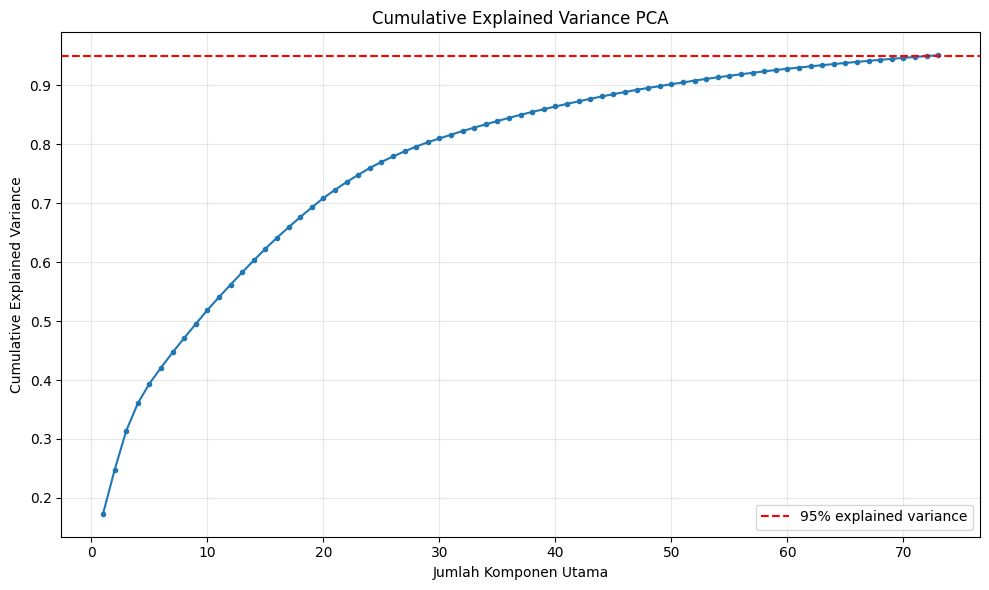

In [70]:
cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o",
    markersize=3
)

plt.axhline(
    y=0.95,
    color="red",
    linestyle="--",
    label="95% explained variance"
)

plt.xlabel("Jumlah Komponen Utama")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance PCA")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

PCA diterapkan setelah standardisasi dan one-hot encoding. Jumlah komponen tidak ditentukan secara sembarang, tetapi dipilih berdasarkan batas cumulative explained variance sebesar 95%. Hasilnya dibandingkan dengan jumlah fitur sebelum PCA untuk menunjukkan besarnya reduksi dimensi.

#### 7. menyusun dan menyimpan dataset

In [71]:
final_dataset = pd.concat(
    [
        id_values.reset_index(drop=True),
        X_pca.reset_index(drop=True),
        target_values.reset_index(drop=True)
    ],
    axis=1
)

In [72]:
print("Ukuran dataset awal:", data_raw.shape)
print("Ukuran dataset akhir:", final_dataset.shape)

print(
    "Total missing value:",
    final_dataset.isnull().sum().sum()
)

print(
    "Jumlah data duplikat:",
    final_dataset.duplicated().sum()
)

print("\nTipe data dataset akhir:")
print(final_dataset.dtypes.value_counts())

display(final_dataset.head())
display(final_dataset.describe())

Ukuran dataset awal: (1460, 81)
Ukuran dataset akhir: (1460, 75)
Total missing value: 0
Jumlah data duplikat: 0

Tipe data dataset akhir:
float64    73
int64       2
Name: count, dtype: int64


,Id,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,...,PC65,PC66,PC67,PC68,PC69,PC70,PC71,PC72,PC73,SalePrice
0,1,2.147222,0.221758,-2.315300,-1.755899,-0.131450,-1.199065,-1.495413,-0.524686,0.397151,...,-0.126461,0.074534,0.159060,0.143558,0.299417,0.048689,0.221676,0.082421,-0.074928,208500
1,2,-0.060681,-1.158217,1.659889,-0.458285,-1.374915,0.396331,1.146815,2.361725,-0.175186,...,-0.283090,-0.024417,-0.238860,-0.353846,-0.090382,0.233562,-0.068296,0.340647,-0.043352,181500
2,3,2.635679,0.141457,-1.698066,-1.430712,-0.773718,-0.722249,-0.255717,-0.635638,-0.504663,...,-0.022933,-0.270043,0.441520,0.182051,0.157003,0.148335,0.348620,-0.005126,-0.058776,223500
3,4,-0.717455,1.567593,0.556813,-0.250229,0.201501,1.572077,-1.785644,-2.352487,0.020052,...,-0.343824,0.392990,-0.582715,0.213968,-0.648545,0.654553,0.537873,-0.113942,-0.802454,140000
4,5,5.192025,1.388611,-0.235504,-1.466551,-0.458691,-0.756742,0.038645,-0.595779,-0.668978,...,-0.021362,-0.047321,-0.049253,0.071434,-0.078731,-0.124815,-0.073348,0.174401,-0.072807,250000


,Id,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,...,PC65,PC66,PC67,PC68,PC69,PC70,PC71,PC72,PC73,SalePrice
count,1460.000000,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03,...,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03,1460.000000
mean,730.500000,1.216683e-18,1.265350e-16,-5.596741e-17,-4.866731e-18,8.638448e-17,-9.246789e-17,-9.611794e-17,-7.056760e-17,-3.041707e-16,...,-3.984636e-17,-2.372531e-17,-1.216683e-18,-4.197556e-17,-7.908438e-17,-2.433366e-18,-5.779243e-18,-6.539670e-17,-6.691755e-17,180921.195890
std,421.610009,2.922829e+00,1.917416e+00,1.811338e+00,1.518576e+00,1.284056e+00,1.156668e+00,1.129586e+00,1.101125e+00,1.084714e+00,...,3.024765e-01,2.991289e-01,2.951131e-01,2.928047e-01,2.858314e-01,2.821146e-01,2.788317e-01,2.703603e-01,2.657209e-01,79442.502883
min,1.000000,-6.783814e+00,-4.745474e+00,-5.724222e+00,-5.838644e+00,-3.361625e+00,-3.056571e+00,-7.611937e+00,-5.120239e+00,-8.158991e+00,...,-1.211366e+00,-1.253034e+00,-1.408547e+00,-1.022056e+00,-1.250938e+00,-1.328454e+00,-8.185229e-01,-7.224776e-01,-9.256638e-01,34900.000000
25%,365.750000,-2.395415e+00,-1.414937e+00,-1.140724e+00,-1.083727e+00,-8.174587e-01,-8.308415e-01,-7.094254e-01,-6.842451e-01,-6.650961e-01,...,-2.057952e-01,-1.714793e-01,-1.887438e-01,-1.812861e-01,-1.838550e-01,-1.619157e-01,-1.880391e-01,-1.699597e-01,-1.668970e-01,129975.000000
50%,730.500000,-2.325462e-01,-2.876401e-01,1.163193e-01,-3.428355e-03,-1.949479e-01,-6.903980e-02,-8.638447e-03,-9.834214e-02,-6.337235e-03,...,-1.729482e-02,1.165555e-02,2.027142e-03,-4.756630e-03,-5.233668e-04,-4.145105e-03,-2.041148e-02,-2.637638e-02,-7.612503e-03,163000.000000
75%,1095.250000,2.122747e+00,1.375344e+00,1.177118e+00,8.461892e-01,5.330472e-01,7.357070e-01,6.467739e-01,5.168268e-01,7.038499e-01,...,1.851143e-01,1.786909e-01,1.780406e-01,1.730886e-01,1.955187e-01,1.539350e-01,1.945470e-01,1.046413e-01,1.747730e-01,214000.000000
max,1460.000000,1.151951e+01,8.674494e+00,9.379242e+00,4.431146e+00,6.870108e+00,7.099268e+00,4.100483e+00,6.217225e+00,3.276463e+00,...,1.099077e+00,1.181919e+00,1.570385e+00,1.073612e+00,1.553222e+00,1.268778e+00,1.206352e+00,1.120840e+00,9.739463e-01,755000.000000


In [74]:
output_csv = "5054251008_Hilal TSabitul Azmi Arba'i_Tugas_Praproses_Data.csv"

final_dataset.to_csv(
    output_csv,
    index=False
)

print(f"Dataset akhir disimpan sebagai: {output_csv}")

Dataset akhir disimpan sebagai: 5054251008_Hilal TSabitul Azmi Arba'i_Tugas_Praproses_Data.csv


In [75]:
df_validation = pd.read_csv(output_csv)

print("Ukuran CSV setelah dibaca kembali:", df_validation.shape)
display(df_validation.head())

Ukuran CSV setelah dibaca kembali: (1460, 75)


,Id,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,...,PC65,PC66,PC67,PC68,PC69,PC70,PC71,PC72,PC73,SalePrice
0,1,2.147222,0.221758,-2.315300,-1.755899,-0.131450,-1.199065,-1.495413,-0.524686,0.397151,...,-0.126461,0.074534,0.159060,0.143558,0.299417,0.048689,0.221676,0.082421,-0.074928,208500
1,2,-0.060681,-1.158217,1.659889,-0.458285,-1.374915,0.396331,1.146815,2.361725,-0.175186,...,-0.283090,-0.024417,-0.238860,-0.353846,-0.090382,0.233562,-0.068296,0.340647,-0.043352,181500
2,3,2.635679,0.141457,-1.698066,-1.430712,-0.773718,-0.722249,-0.255717,-0.635638,-0.504663,...,-0.022933,-0.270043,0.441520,0.182051,0.157003,0.148335,0.348620,-0.005126,-0.058776,223500
3,4,-0.717455,1.567593,0.556813,-0.250229,0.201501,1.572077,-1.785644,-2.352487,0.020052,...,-0.343824,0.392990,-0.582715,0.213968,-0.648545,0.654553,0.537873,-0.113942,-0.802454,140000
4,5,5.192025,1.388611,-0.235504,-1.466551,-0.458691,-0.756742,0.038645,-0.595779,-0.668978,...,-0.021362,-0.047321,-0.049253,0.071434,-0.078731,-0.124815,-0.073348,0.174401,-0.072807,250000


#### kesimpulan

Dataset telah melalui tahapan pembersihan, penanganan outlier, transformasi, dan reduksi dimensi. Kolom dengan missing value di atas 50% dihapus, sedangkan missing value yang tersisa diimputasi berdasarkan tipe atribut. Outlier pada atribut numerik terpilih ditangani menggunakan IQR capping. Atribut kategoris diubah menggunakan one-hot encoding dan atribut numerik distandarisasi. Redundansi fitur dikurangi melalui analisis korelasi, kemudian PCA digunakan untuk mempertahankan 95% cumulative explained variance. Dataset akhir tidak memiliki missing value dan seluruh fitur hasil reduksi telah berbentuk numerik.